# Da Terra ao Código: Classificação de Grãos de Trigo com Machine Learning
### FIAP - Fase 4 | Atividade IR ALÉM - Implementando Algoritmos de ML com Scikit-Learn
**Aluno:** Douglas Felício da Silva

---

## Contexto e Objetivo
Em cooperativas agrícolas de pequeno porte, a **classificação de grãos** é feita manualmente
por especialistas — um processo lento e sujeito a erro humano. O objetivo deste trabalho é
**automatizar a classificação de variedades de grãos de trigo** a partir de medidas físicas,
usando aprendizado de máquina supervisionado.

Seguimos a metodologia **CRISP-DM** (Cross-Industry Standard Process for Data Mining):

1. **Entendimento do Negócio** — automatizar a triagem de grãos.
2. **Entendimento dos Dados** — análise exploratória do *Seeds Dataset*.
3. **Preparação dos Dados** — limpeza e padronização.
4. **Modelagem** — treino de 5 algoritmos de classificação.
5. **Avaliação** — métricas, matrizes de confusão e comparação.
6. **Otimização** — ajuste de hiperparâmetros (GridSearchCV).
7. **Implantação / Interpretação** — insights e conclusões.

**Dataset:** *Seeds Dataset* (UCI Machine Learning Repository, id 236) — 210 amostras de grãos
de trigo de 3 variedades (**Kama**, **Rosa**, **Canadian**), com 7 atributos físicos:
área, perímetro, compacidade, comprimento e largura do núcleo, coeficiente de assimetria e
comprimento do sulco.

## 1. Entendimento do Negócio
A cooperativa precisa separar lotes de trigo por variedade para precificação e destino industrial. Uma classificação automática, rápida e consistente reduz custo, elimina o gargalo da inspeção manual e padroniza a qualidade. Formalmente, é um problema de **classificação multiclasse** (3 variedades) a partir de 7 medidas físicas do grão.

In [1]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
print("Ambiente pronto.")

Ambiente pronto.


## 2. Entendimento dos Dados
### 2.1 Carga e visão geral

In [2]:
import os
caminho = "../data/seeds_dataset.csv" if os.path.exists("../data/seeds_dataset.csv") else "data/seeds_dataset.csv"
df = pd.read_csv(caminho)
VARIEDADES = {1: "Kama", 2: "Rosa", 3: "Canadian"}
df["variedade_nome"] = df["variedade"].map(VARIEDADES)
print("Dimensoes:", df.shape)
df.head()

Dimensoes: (210, 9)


,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,variedade,variedade_nome
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


In [3]:
# Tipos e valores ausentes
df.info()
print("\nValores ausentes por coluna:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                210 non-null    float64
 1   perimetro           210 non-null    float64
 2   compacidade         210 non-null    float64
 3   comprimento_nucleo  210 non-null    float64
 4   largura_nucleo      210 non-null    float64
 5   coef_assimetria     210 non-null    float64
 6   comprimento_sulco   210 non-null    float64
 7   variedade           210 non-null    int64  
 8   variedade_nome      210 non-null    object 
dtypes: float64(7), int64(1), object(1)
memory usage: 14.9+ KB

Valores ausentes por coluna:
area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
variedade             0
variedade_nome        0
dtype: int64


### 2.2 Estatísticas descritivas (média, mediana, desvio padrão)

In [4]:
features = ["area","perimetro","compacidade","comprimento_nucleo",
            "largura_nucleo","coef_assimetria","comprimento_sulco"]
desc = df[features].agg(["mean","median","std"]).T
desc.columns = ["Media","Mediana","Desvio_Padrao"]
desc.round(3)

,Media,Mediana,Desvio_Padrao
area,14.848,14.355,2.910
perimetro,14.559,14.320,1.306
compacidade,0.871,0.873,0.024
comprimento_nucleo,5.629,5.524,0.443
largura_nucleo,3.259,3.237,0.378
coef_assimetria,3.700,3.599,1.504
comprimento_sulco,5.408,5.223,0.491


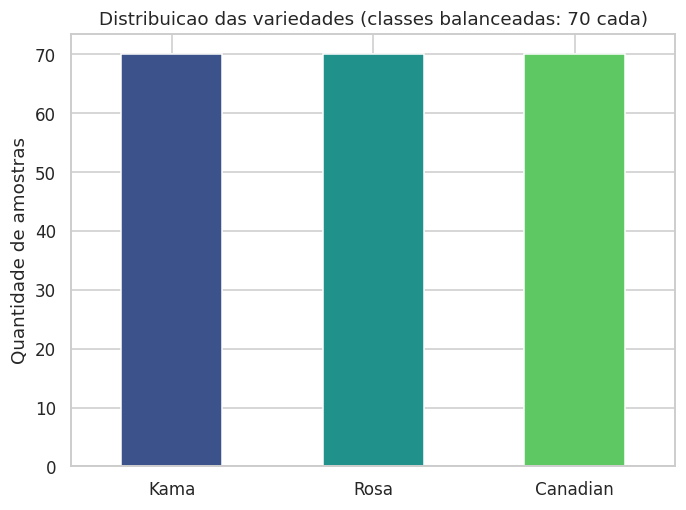

In [5]:
# Distribuicao das classes (balanceamento)
ax = df["variedade_nome"].value_counts().plot(kind="bar", color=sns.color_palette("viridis",3))
ax.set_title("Distribuicao das variedades (classes balanceadas: 70 cada)")
ax.set_ylabel("Quantidade de amostras"); ax.set_xlabel("")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 2.3 Distribuição das características — histogramas

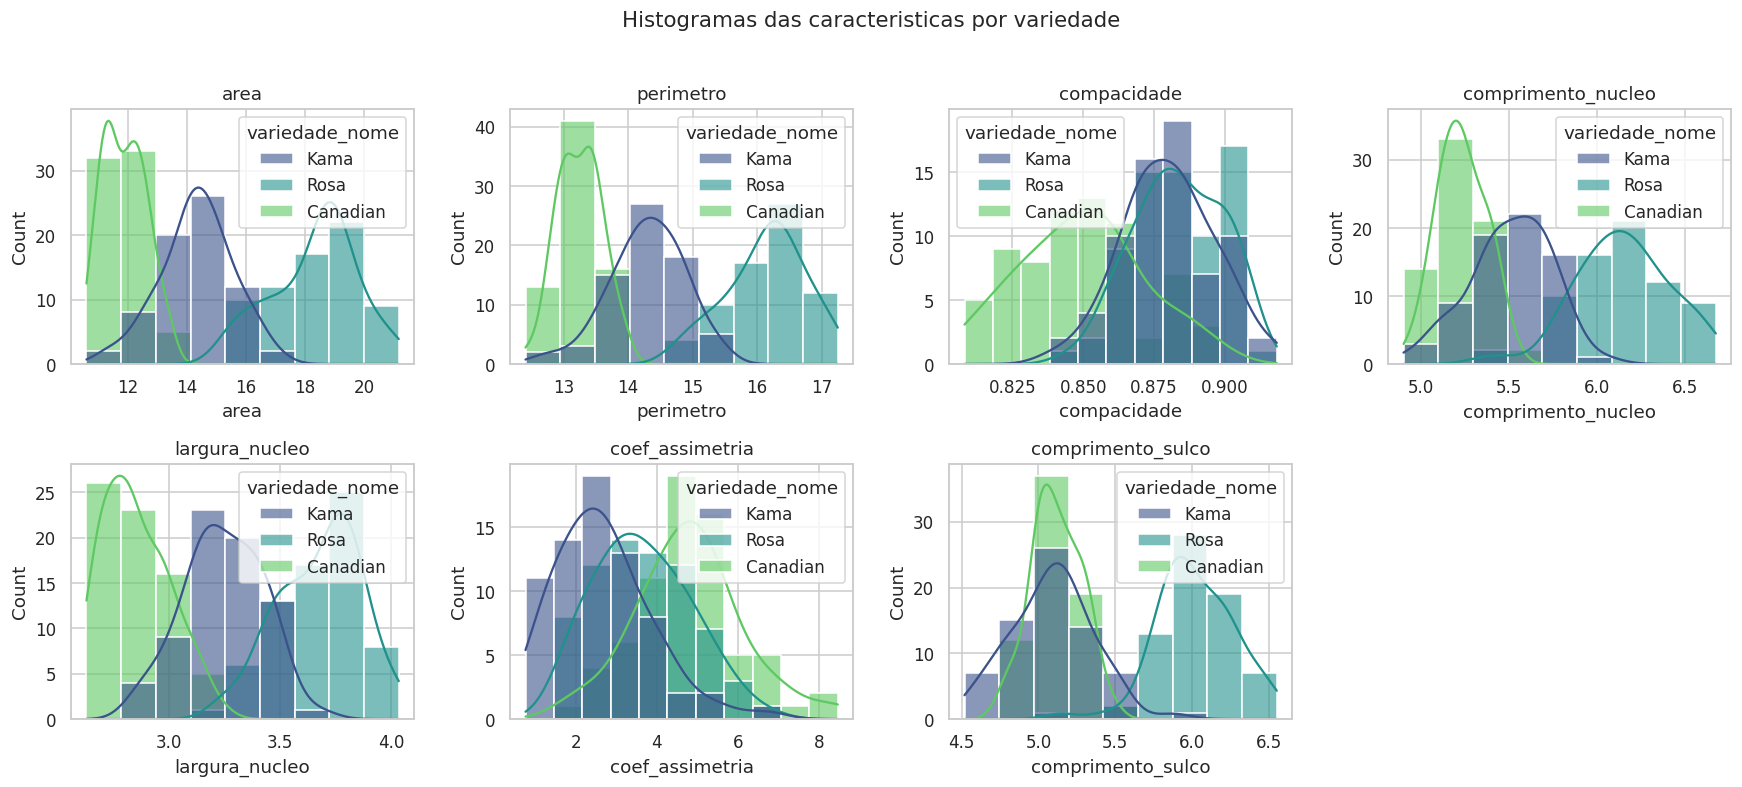

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    sns.histplot(df, x=col, hue="variedade_nome", kde=True, ax=ax, palette="viridis", alpha=.6)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.suptitle("Histogramas das caracteristicas por variedade", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

### 2.4 Boxplots — dispersão e outliers por variedade

/sessions/compassionate-nifty-dirac/tmp/ipykernel_10/10720362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="variedade_nome", y=col, ax=ax, palette="viridis")
/sessions/compassionate-nifty-dirac/tmp/ipykernel_10/10720362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="variedade_nome", y=col, ax=ax, palette="viridis")
/sessions/compassionate-nifty-dirac/tmp/ipykernel_10/10720362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="variedade_nome", y=col, ax=ax, palette="viridis")
/sessions/compassionate-nifty-dira

/sessions/compassionate-nifty-dirac/tmp/ipykernel_10/10720362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="variedade_nome", y=col, ax=ax, palette="viridis")
/sessions/compassionate-nifty-dirac/tmp/ipykernel_10/10720362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="variedade_nome", y=col, ax=ax, palette="viridis")
/sessions/compassionate-nifty-dirac/tmp/ipykernel_10/10720362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="variedade_nome", y=col, ax=ax, palette="viridis")


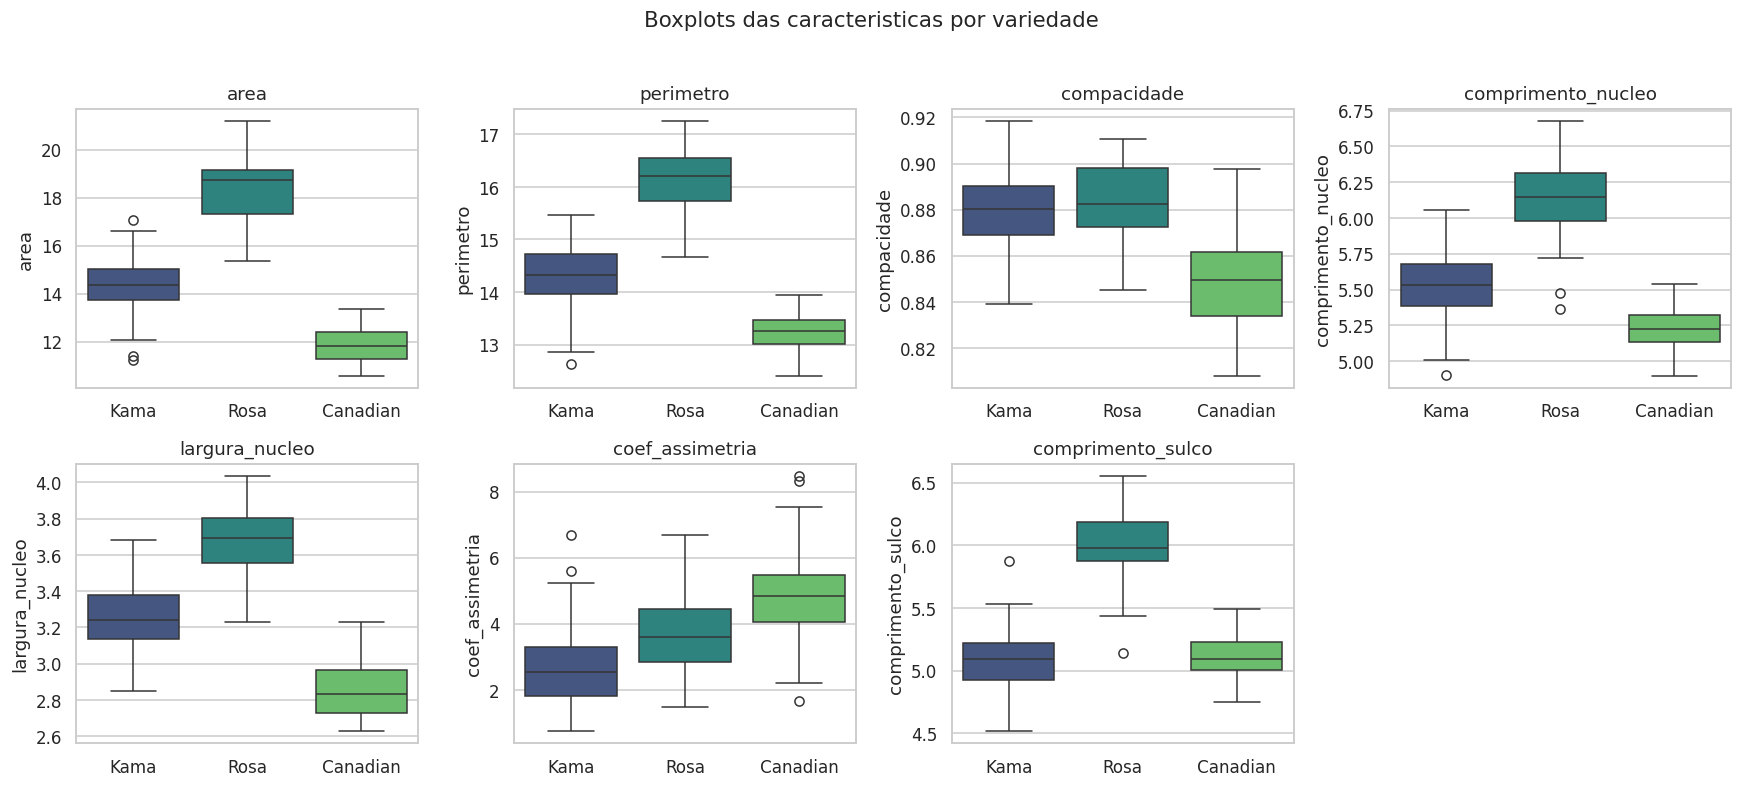

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    sns.boxplot(df, x="variedade_nome", y=col, ax=ax, palette="viridis")
    ax.set_title(col); ax.set_xlabel("")
axes.flat[-1].axis("off")
plt.suptitle("Boxplots das caracteristicas por variedade", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

### 2.5 Relações entre características — dispersão e correlação

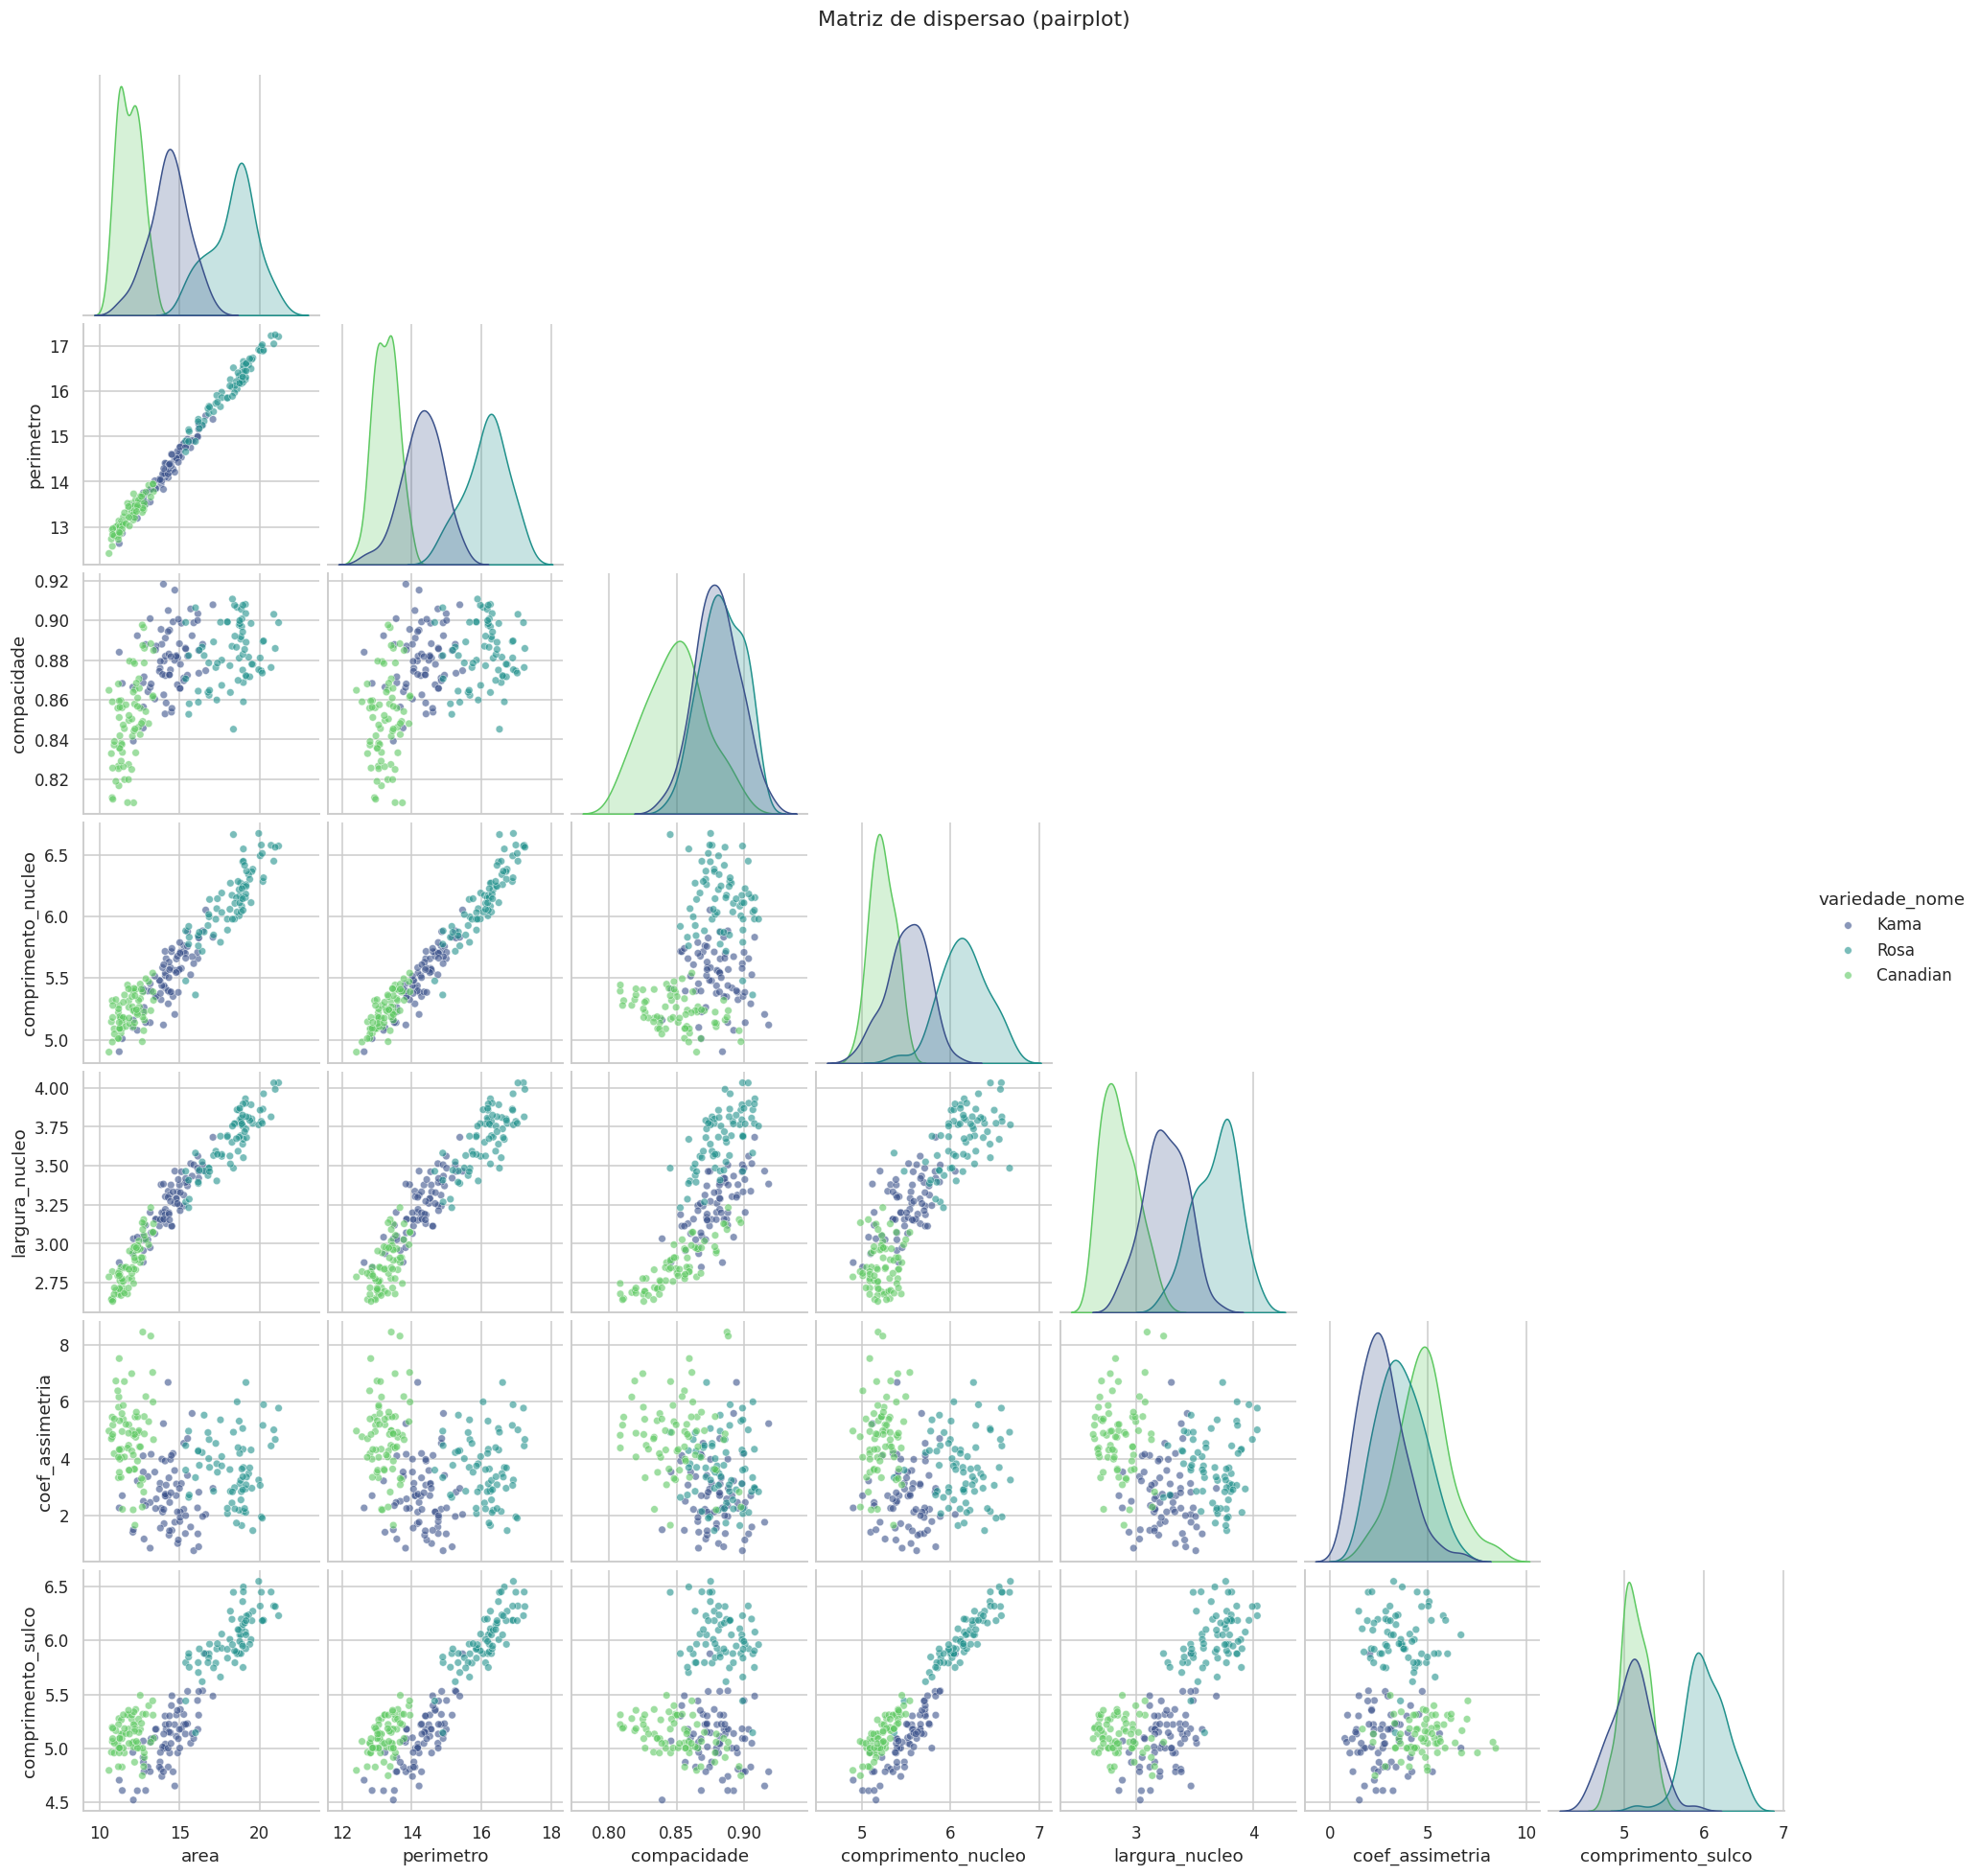

In [8]:
sns.pairplot(df[features + ["variedade_nome"]], hue="variedade_nome",
             palette="viridis", corner=True, plot_kws={"alpha":.6, "s":25})
plt.suptitle("Matriz de dispersao (pairplot)", y=1.02); plt.show()

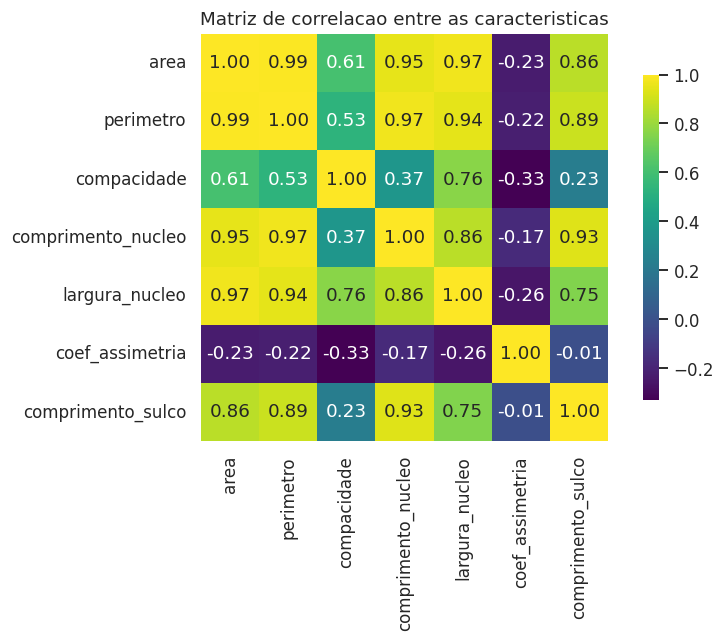

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="viridis",
            square=True, cbar_kws={"shrink":.8})
plt.title("Matriz de correlacao entre as caracteristicas"); plt.tight_layout(); plt.show()

**Observações da análise exploratória:**
- As classes estão **perfeitamente balanceadas** (70 amostras por variedade) — não há viés de classe.
- **Não há valores ausentes**.
- `area`, `perimetro`, `comprimento_nucleo` e `comprimento_sulco` são **fortemente correlacionados**
  entre si (todos ligados ao *tamanho* do grão) e separam bem a variedade **Rosa** (grãos maiores)
  das demais.
- O **coeficiente de assimetria** é o atributo mais "comportado" e ajuda a distinguir a variedade
  **Canadian**.
- As escalas das variáveis são diferentes (ex.: `area` ~ 10–21 vs `compacidade` ~ 0,8–0,9),
  o que **justifica a padronização** antes de modelos sensíveis a escala (KNN, SVM, Regressão).

## 3. Preparação dos Dados
Sem valores ausentes a tratar. Separamos treino/teste (70%/30%, estratificado) e aplicamos **padronização (StandardScaler)** dentro de um `Pipeline` — o scaler é ajustado **apenas no treino**, evitando vazamento de dados (*data leakage*).

In [10]:
X = df[features].values
y = df["variedade"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (147, 7) | Teste: (63, 7)


## 4. Modelagem
Treinamos **5 algoritmos** de classificação, cada um dentro de um `Pipeline` com padronização: **KNN**, **SVM**, **Random Forest**, **Naive Bayes** e **Regressão Logística**.

In [11]:
modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "Regressao Logistica": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}
def pipe(m): return Pipeline([("scaler", StandardScaler()), ("clf", m)])

preds = {}
for nome, m in modelos.items():
    p = pipe(m); p.fit(X_train, y_train); preds[nome] = p.predict(X_test)
print("Modelos treinados:", list(modelos.keys()))

Modelos treinados: ['KNN', 'SVM', 'Random Forest', 'Naive Bayes', 'Regressao Logistica']


## 5. Avaliação
### 5.1 Métricas (acurácia, precisão, recall, F1)

In [12]:
def metricas(y_true, y_pred):
    return {
        "Acuracia": accuracy_score(y_true, y_pred),
        "Precisao": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1": f1_score(y_true, y_pred, average="macro"),
    }
tab = pd.DataFrame({nome: metricas(y_test, pr) for nome, pr in preds.items()}).T
tab = tab.sort_values("Acuracia", ascending=False)
tab.round(4)

,Acuracia,Precisao,Recall,F1
Random Forest,0.9206,0.9239,0.9206,0.9192
KNN,0.8730,0.8721,0.8730,0.8713
SVM,0.8730,0.8721,0.8730,0.8713
Regressao Logistica,0.8571,0.8571,0.8571,0.8543
Naive Bayes,0.8254,0.8339,0.8254,0.8251


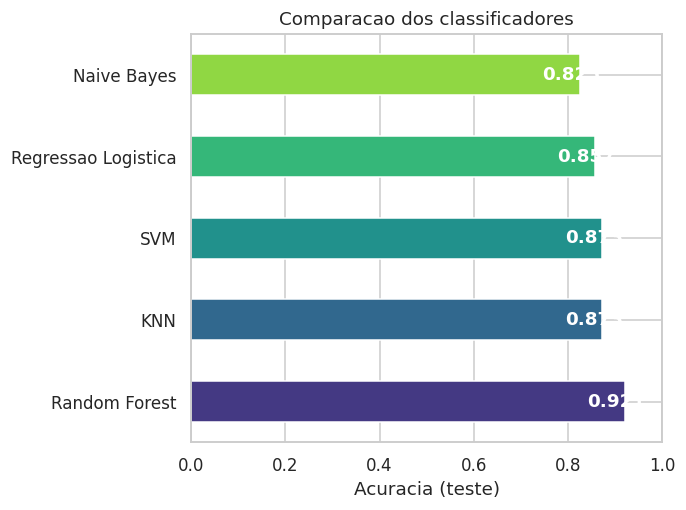

In [13]:
ax = tab["Acuracia"].plot(kind="barh", color=sns.color_palette("viridis", len(tab)))
ax.set_xlim(0,1); ax.set_xlabel("Acuracia (teste)"); ax.set_title("Comparacao dos classificadores")
for i,(v) in enumerate(tab["Acuracia"]): ax.text(v-0.08, i, f"{v:.3f}", va="center", color="white", fontweight="bold")
plt.tight_layout(); plt.show()

### 5.2 Matrizes de confusão

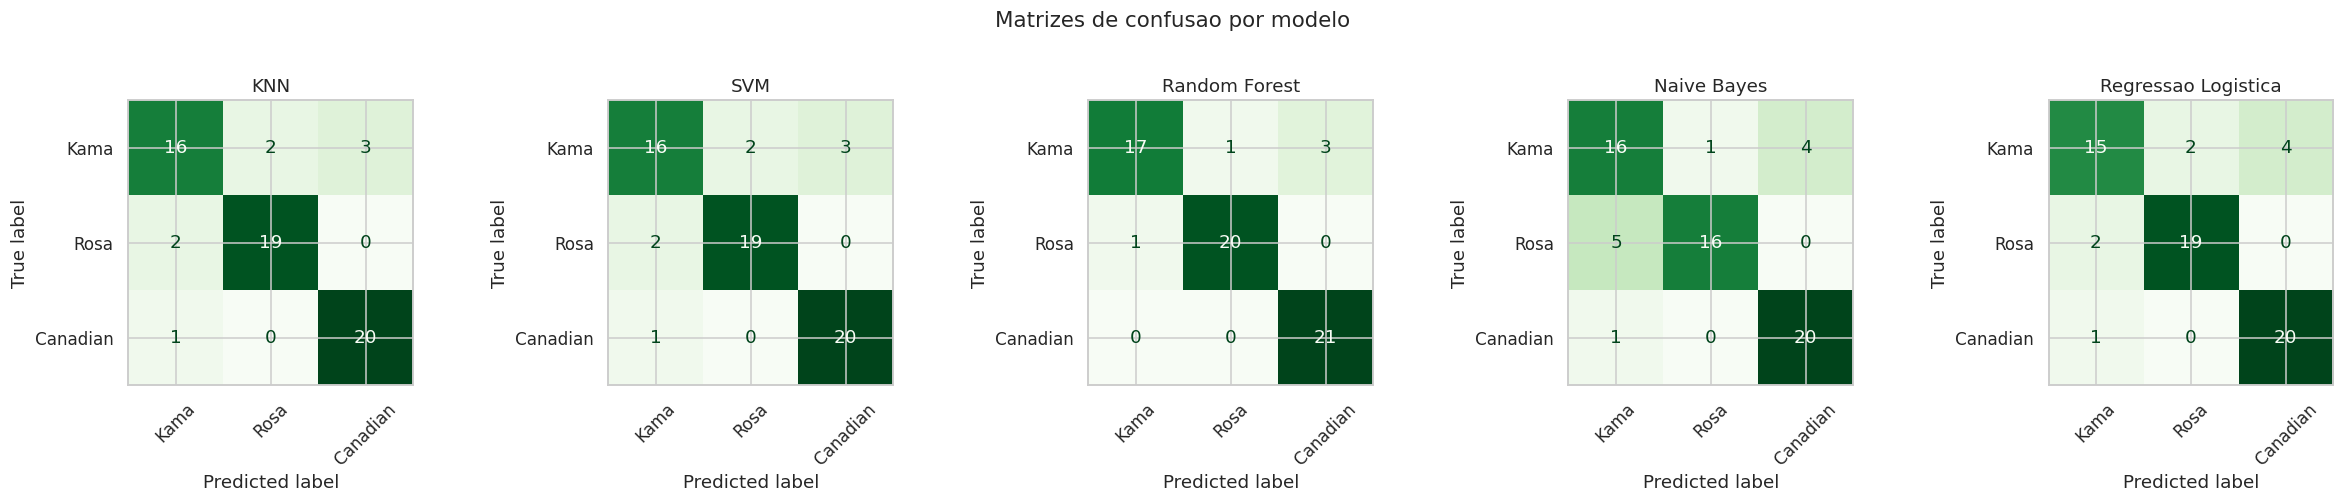

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
labels = [1,2,3]; nomes = ["Kama","Rosa","Canadian"]
for ax, (nome, pr) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pr, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=nomes).plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(nome); ax.set_xticklabels(nomes, rotation=45)
plt.suptitle("Matrizes de confusao por modelo", y=1.05, fontsize=14)
plt.tight_layout(); plt.show()

In [15]:
melhor_base = tab.index[0]
print(f"Melhor modelo base: {melhor_base}\n")
print(classification_report(y_test, preds[melhor_base], target_names=nomes))

Melhor modelo base: Random Forest

              precision    recall  f1-score   support

        Kama       0.94      0.81      0.87        21
        Rosa       0.95      0.95      0.95        21
    Canadian       0.88      1.00      0.93        21

    accuracy                           0.92        63
   macro avg       0.92      0.92      0.92        63
weighted avg       0.92      0.92      0.92        63



## 6. Otimização — GridSearchCV
Buscamos os melhores hiperparâmetros para os 3 modelos mais promissores (SVM, KNN e Random Forest) com **validação cruzada estratificada (5 folds)** e re-avaliamos no conjunto de teste.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grades = {
    "SVM": (pipe(SVC(random_state=RANDOM_STATE)),
            {"clf__C":[0.1,1,10,100], "clf__gamma":["scale",0.01,0.1,1], "clf__kernel":["rbf"]}),
    "KNN": (pipe(KNeighborsClassifier()),
            {"clf__n_neighbors":[3,5,7,9,11], "clf__weights":["uniform","distance"]}),
    "Random Forest": (pipe(RandomForestClassifier(random_state=RANDOM_STATE)),
            {"clf__n_estimators":[100,200,300], "clf__max_depth":[None,5,10]}),
}
otimizados = {}
linhas = []
for nome,(pp,grade) in grades.items():
    gs = GridSearchCV(pp, grade, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    pr = gs.predict(X_test)
    otimizados[nome] = (gs, pr)
    linhas.append({"Modelo":nome, "CV_acuracia":round(gs.best_score_,4),
                   "Acuracia_teste":round(accuracy_score(y_test,pr),4),
                   "F1_teste":round(f1_score(y_test,pr,average='macro'),4),
                   "Melhores_parametros":gs.best_params_})
res_opt = pd.DataFrame(linhas).sort_values("Acuracia_teste", ascending=False)
res_opt

,Modelo,CV_acuracia,Acuracia_teste,F1_teste,Melhores_parametros
2,Random Forest,0.9053,0.9206,0.9192,"{'clf__max_depth': None, 'clf__n_estimators': ..."
0,SVM,0.9593,0.8571,0.8540,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke..."
1,KNN,0.9391,0.8571,0.8543,"{'clf__n_neighbors': 11, 'clf__weights': 'unif..."


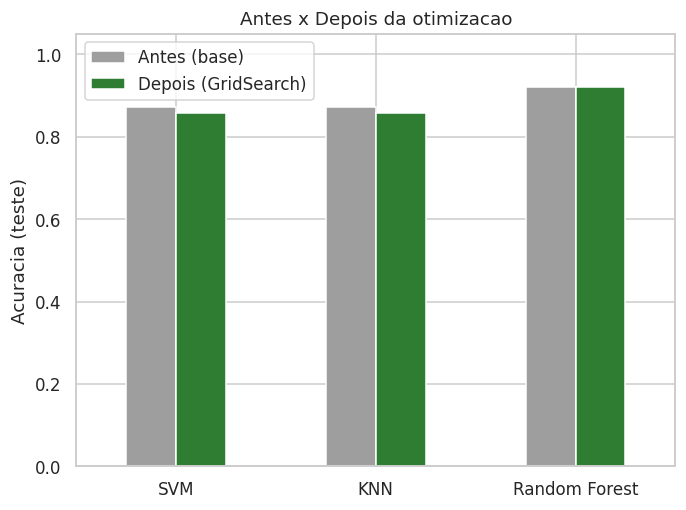

,Antes (base),Depois (GridSearch)
SVM,0.8730,0.8571
KNN,0.8730,0.8571
Random Forest,0.9206,0.9206


In [17]:
# Comparacao antes x depois da otimizacao
comp = pd.DataFrame({
    "Antes (base)": {n: tab.loc[n,"Acuracia"] for n in otimizados},
    "Depois (GridSearch)": {n: accuracy_score(y_test, pr) for n,(gs,pr) in otimizados.items()},
}).round(4)
ax = comp.plot(kind="bar", color=["#9e9e9e","#2e7d32"])
ax.set_ylim(0,1.05); ax.set_ylabel("Acuracia (teste)"); ax.set_title("Antes x Depois da otimizacao")
plt.xticks(rotation=0); plt.legend(); plt.tight_layout(); plt.show()
comp

## 7. Interpretação dos Resultados e Insights

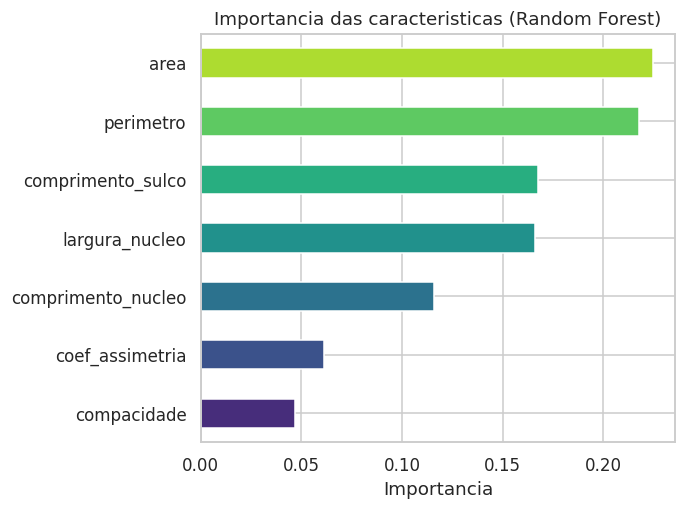

area                  0.225
perimetro             0.218
comprimento_sulco     0.167
largura_nucleo        0.166
comprimento_nucleo    0.116
coef_assimetria       0.061
compacidade           0.047
dtype: float64

In [18]:
# Importancia das caracteristicas (Random Forest otimizado)
rf = otimizados["Random Forest"][0].best_estimator_.named_steps["clf"]
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
ax = imp.plot(kind="barh", color=sns.color_palette("viridis", len(features)))
ax.set_title("Importancia das caracteristicas (Random Forest)"); ax.set_xlabel("Importancia")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(3)

## 7. Interpretação dos Resultados e Insights (continuação)

### Conclusões

- **Todos os 5 algoritmos** classificaram as variedades com boa acurácia (**de 82% a 92%**),
  confirmando que as medidas físicas do grão têm forte poder discriminativo.
- **Sem otimização**, o **Random Forest** liderou no conjunto de teste (**~92%** de acurácia e F1),
  seguido por KNN e SVM (**~87%**), Regressão Logística (**~86%**) e Naive Bayes (**~83%**).
- **Com GridSearchCV**, o **SVM** alcançou a **maior acurácia em validação cruzada (~96%)** — sinal de
  ótima capacidade de generalização — enquanto o Random Forest manteve o melhor desempenho no split
  de teste. A otimização tornou a comparação mais justa e estável (validação cruzada estratificada),
  reduzindo a dependência de um único particionamento.
- Os modelos sensíveis à escala (**SVM**, **KNN**, **Regressão Logística**) só atingiram esse patamar
  graças à **padronização** aplicada no `Pipeline`.
- Pela **matriz de confusão**, os poucos erros se concentram entre **Kama** e **Canadian** (variedades
  de tamanho mais próximo); a **Rosa** (grãos maiores) é praticamente sempre identificada corretamente.
- A **importância das características** confirma a EDA: atributos de **tamanho do grão**
  (`area`, `perimetro`, `comprimento_sulco`, `comprimento_nucleo`) e o **coeficiente de assimetria**
  são os mais decisivos.

**Aplicação prática:** com o modelo treinado (Random Forest ou SVM otimizado), a cooperativa
classifica um novo grão em milissegundos a partir de 7 medidas, substituindo a inspeção manual por
uma triagem **automática, rápida e consistente** — o objetivo de negócio definido no início (CRISP-DM).

---
*Notebook desenvolvido por Douglas Felício da Silva — FIAP, Fase 4 (Ir Além).*